# DeSFAM SyscallAD — DongTing Training (replication)

Reproduces the **SyscallAD** detector from the DeSFAM paper (Dong et al.) on the **DongTing** dataset, with notes on every deviation from the released code.

| Stage | What |
|---|---|
| 1. Load | Read 18,966 syscall sequences from MongoDB (`syzbot_DB`) |
| 2. Split | Per-trace `DTDS-train / DTDS-validation / DTDS-test` |
| 3. Vocab | Top-K freq, discriminative, bigrams, **categorical (paper §IV.B.1, new)** |
| 4. Window | Sliding window length 15, stride 3 (paper §IV.B.1) |
| 5. Featurise | Per-trace batched numpy + per-split window cap (memory safe) |
| 6. Scale | RobustScaler fitted on normal-only, in-place float32 |
| 7. IF | Isolation Forest, 300 trees |
| 8. VAE | 3 seeds × ≤80 epochs, EarlyStopping (patience 5) |
| 9. Ensemble | `α·VAE + (1-α)·IF`, α tuned on val |
| 10. Threshold | Vectorised F1 sweep |

**Feature vector layout (159 dims):** `freq_60 | disc_40 | stats_8 | bigrams_40 | ver_1 | cat_10`

Paper components **not** reproducible from DongTing: temporal Δt features (no timestamps), PrefixSpan access list (not in released artefacts), data augmentation (incompatible with normal-only training).


## 1. Setup

Import from `train.py` (single source of truth — notebook adds plots + narrative on top).


In [1]:
import os, json, warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

from pathlib import Path
import numpy as np
import joblib
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve

from train import (
    CFG, GLOBAL_SEED, set_seeds,
    load_syscall_table, load_sequences,
    fit_vocab, build_features_windowed,
    SYSCALL_CATEGORIES, build_id_to_category,
    build_vae, recon_error,
    EnsembleScorer,
    select_threshold, compute_metrics,
    WINDOW_LEN, WINDOW_STRIDE, USE_SLIDING_WINDOW, USE_CATEGORIES,
    MAX_WINDOWS_PER_SPLIT,
)

MONGO_URI   = os.environ.get('MONGO_URI',   'mongodb://mongo:27017/')
MONGO_DB    = os.environ.get('MONGO_DB',    'syzbot_DB')
SYSCALL_TBL = os.environ.get('SYSCALL_TBL', '/data/dongting_repo/syscall_64.tbl')
OUTPUT_DIR  = os.environ.get('OUTPUT_DIR',  '/model')
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
set_seeds(GLOBAL_SEED)

print(f'TensorFlow {tf.__version__}  NumPy {np.__version__}')
print(f'Window: length={WINDOW_LEN}  stride={WINDOW_STRIDE}  cap_per_split={MAX_WINDOWS_PER_SPLIT:,}')
print(f'Output dir: {OUTPUT_DIR}')


TensorFlow 2.21.0  NumPy 2.4.6
Window: length=15  stride=3  cap_per_split=2,000,000
Output dir: /model


## 2. Syscall table

Maps every syscall **name** ↔ **id** from the kernel `syscall_64.tbl`.


In [2]:
name_to_id = load_syscall_table(SYSCALL_TBL)
id_to_name = {v: k for k, v in name_to_id.items()}
print(f'{len(name_to_id)} syscalls in table')
print(f'  examples: open={name_to_id["open"]}  execve={name_to_id["execve"]}  clone={name_to_id["clone"]}')


362 syscalls in table
  examples: open=2  execve=520  clone=56


## 3. Load sequences from MongoDB

For each baseline document, look up the matching normal/attack syscall trace and emit `(seq, label, split, kernel_version)`.


In [3]:
seqs, labels, splits, ver_list = load_sequences(name_to_id)
print(f'Loaded {len(seqs):,} sequences total')

# Split partitions
idx_train = [i for i, s in enumerate(splits) if s == 'train']
idx_val   = [i for i, s in enumerate(splits) if s == 'val']
idx_test  = [i for i, s in enumerate(splits) if s == 'test']

seqs_train = [seqs[i] for i in idx_train];  ver_train = [ver_list[i] for i in idx_train]
seqs_val   = [seqs[i] for i in idx_val];    ver_val   = [ver_list[i] for i in idx_val]
seqs_test  = [seqs[i] for i in idx_test];   ver_test  = [ver_list[i] for i in idx_test]
y_train = np.array([labels[i] for i in idx_train], dtype=np.int32)
y_val   = np.array([labels[i] for i in idx_val],   dtype=np.int32)
y_test  = np.array([labels[i] for i in idx_test],  dtype=np.int32)

for name, y in [('train', y_train), ('val', y_val), ('test', y_test)]:
    print(f'  {name:5s}: n={len(y):,}  normal={(y==0).sum():,}  attack={(y==1).sum():,}')


[00:00  ram= 0.6G]    Indexing normal sequences from Mongo...


[00:00  ram= 0.8G]    Indexing attack sequences from Mongo...


[00:07  ram= 3.6G]    Indexed normal=6,850  attack=10,079


[00:07  ram= 3.6G]    Reading baseline index...


  Loaded 15892 sequences (3074 skipped)
Loaded 15,892 sequences total
  train: n=12,464  normal=5,401  attack=7,063
  val  : n=1,443  normal=675  attack=768
  test : n=1,985  normal=669  attack=1,316


## 4. Trace-length distribution

DongTing attack traces (from syzkaller fuzz outputs) are **far longer** than normal traces. With stride 3 sliding windows, the train split would expand to >100 M windows uncapped — the per-split cap (default 2 M) keeps memory bounded.


NORMAL  n=6,745  median=61  p95=2,216  max=1,419,684
ATTACK  n=9,147  median=37  p95=49,194  max=2,722,485


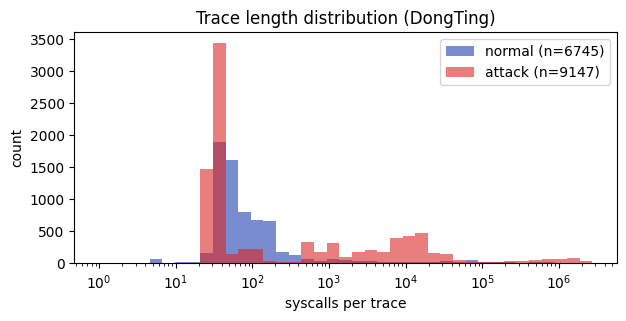

In [4]:
all_lens_n = np.array([len(s) for i, s in enumerate(seqs) if labels[i] == 0])
all_lens_a = np.array([len(s) for i, s in enumerate(seqs) if labels[i] == 1])

print(f'NORMAL  n={len(all_lens_n):,}  median={int(np.median(all_lens_n)):,}  '
      f'p95={int(np.percentile(all_lens_n, 95)):,}  max={int(all_lens_n.max()):,}')
print(f'ATTACK  n={len(all_lens_a):,}  median={int(np.median(all_lens_a)):,}  '
      f'p95={int(np.percentile(all_lens_a, 95)):,}  max={int(all_lens_a.max()):,}')

fig, ax = plt.subplots(figsize=(7, 3))
bins = np.logspace(0, np.log10(max(all_lens_n.max(), all_lens_a.max()) + 1), 40)
ax.hist(all_lens_n, bins=bins, alpha=0.6, label=f'normal (n={len(all_lens_n)})', color='#1e40af')
ax.hist(all_lens_a, bins=bins, alpha=0.6, label=f'attack (n={len(all_lens_a)})', color='#dc2626')
ax.set_xscale('log'); ax.set_xlabel('syscalls per trace'); ax.set_ylabel('count'); ax.legend()
ax.set_title('Trace length distribution (DongTing)')
plt.show()


## 5. Vocabulary + syscall categories

Vocab is fit on **normal training traces only** so attack-specific syscalls don't bias the feature space.

The categorical-frequency block (paper §IV.B.1, **missing from released code**) maps each syscall to a functional category — file / memory / network / process / signal / time / IPC / security / I/O event / other. Per-window category frequency is appended as 10 extra columns.


In [5]:
normal_train_seqs = [seqs_train[i] for i in range(len(seqs_train)) if y_train[i] == 0]
normal_train_ver  = [ver_train[i]  for i in range(len(seqs_train)) if y_train[i] == 0]

top_ids, disc_ids, top_ngrams, ver_cols = fit_vocab(
    normal_train_seqs, normal_train_ver,
    CFG['top_k_freq'], CFG['top_k_disc'], CFG['top_k_ngrams'], CFG['ngram_n'],
)

# Categorical block
cat_cols  = list(SYSCALL_CATEGORIES) if USE_CATEGORIES else []
id_to_cat = build_id_to_category(name_to_id) if USE_CATEGORIES else None

n_freq, n_disc = len(top_ids), len(disc_ids)
n_ng, n_ver, n_cat = len(top_ngrams), len(ver_cols), len(cat_cols)
feat_dim = n_freq + n_disc + 8 + n_ng + n_ver + n_cat

print(f'freq_{n_freq} | disc_{n_disc} | stats_8 | bigrams_{n_ng} | ver_{n_ver} | cat_{n_cat}  → {feat_dim} dims')
print(f'top-10 syscalls: {[id_to_name.get(x, str(x)) for x in top_ids[:10]]}')
print(f'cat_cols: {cat_cols}')

# Category coverage check
if id_to_cat:
    from collections import Counter
    cat_dist = Counter(id_to_cat.values())
    for c in cat_cols:
        print(f'  {c:10s} {cat_dist.get(c, 0):3d} syscalls')


freq_60 | disc_40 | stats_8 | bigrams_40 | ver_1 | cat_10  → 159 dims
top-10 syscalls: ['futex', 'write', 'read', '16', 'close', 'openat', 'rt_sigprocmask', 'mmap', 'lseek', 'mprotect']
cat_cols: ['process', 'file', 'memory', 'network', 'signal', 'time', 'ipc', 'security', 'io_event', 'other']
  process     38 syscalls
  file        94 syscalls
  memory      30 syscalls
  network     18 syscalls
  signal      15 syscalls
  time        22 syscalls
  ipc         18 syscalls
  security    29 syscalls
  io_event    19 syscalls
  other       79 syscalls


## 6. Sliding-window featurise (per-trace batched)

For each trace, generate windows of length 15 with stride 3 using `numpy.lib.stride_tricks.sliding_window_view` (zero-copy). Vectorised `np.bincount` + indexed gather replaces what used to be a per-window Python loop with 150+ scalar writes — ~20× faster and bounded RAM.

The per-split cap (`MAX_WINDOWS_PER_SPLIT = 2M`) is applied via random per-trace subsampling. Without it, the train split alone expands to ~127 M windows — would need ~80 GB just for `X_train`.


In [6]:
def build_split(name, sqs, vrs, yi, seed):
    X, y, dropped = build_features_windowed(
        sqs, vrs, yi, top_ids, disc_ids, top_ngrams, ver_cols,
        WINDOW_LEN, WINDOW_STRIDE, CFG['ngram_n'], cat_cols, id_to_cat,
        max_windows=MAX_WINDOWS_PER_SPLIT, rng_seed=seed,
    )
    print(f'  {name:5s}: traces={len(sqs):,}  → windows={X.shape[0]:,}  '
          f'(dropped {dropped} too-short)')
    return X, y

X_train_full, y_train = build_split('train', seqs_train, ver_train, y_train, GLOBAL_SEED)
X_val,        y_val   = build_split('val',   seqs_val,   ver_val,   y_val,   GLOBAL_SEED + 1)
X_test,       y_test  = build_split('test',  seqs_test,  ver_test,  y_test,  GLOBAL_SEED + 2)

# Free source trace lists
del seqs, ver_list, labels, splits
del seqs_train, ver_train, seqs_val, ver_val, seqs_test, ver_test

print(f'X_train: {X_train_full.shape}   X_val: {X_val.shape}   X_test: {X_test.shape}')
print(f'attack rate: train={y_train.mean():.2%}  val={y_val.mean():.2%}  test={y_test.mean():.2%}')


  Subsampling windows: 126,826,263 → 2,004,929 (cap=2,000,000, ratio=0.016)


[01:32  ram= 7.2G]    featurise: trace 623/12,464 (5%)  rows=396,968/2,004,929


[01:38  ram= 7.3G]    featurise: trace 1,246/12,464 (10%)  rows=616,358/2,004,929


[01:44  ram= 7.5G]    featurise: trace 1,869/12,464 (15%)  rows=846,692/2,004,929


[01:49  ram= 7.6G]    featurise: trace 2,492/12,464 (20%)  rows=1,014,041/2,004,929


...

[04:16  ram=10.4G]    featurise: trace 1,881/1,985 (95%)  rows=1,898,977/1,999,301


[04:19  ram=10.5G]    featurise: trace 1,980/1,985 (100%)  rows=1,998,958/1,999,301


  test : traces=1,985  → windows=1,999,301  (dropped 12 too-short)


X_train: (2004929, 159)   X_val: (1999730, 159)   X_test: (1999301, 159)


attack rate: train=89.09%  val=93.00%  test=84.05%


## 7. RobustScaler (in-place float32)

Fit on the normal-only subset of train (so attack outliers don't shift the centre/scale). Then cast the scaler params to float32 and do `(X − center) / scale` in-place on each split — no float64 temp arrays.


In [7]:
X_train_norm = X_train_full[y_train == 0].astype(np.float32)
print(f'Normal training windows: {X_train_norm.shape[0]:,}  ({X_train_norm.shape[0]/X_train_full.shape[0]:.1%} of train)')
del X_train_full   # free ~1 GB

feature_scaler = RobustScaler(quantile_range=(1.0, 99.0))
feature_scaler.fit(X_train_norm)
feature_scaler.center_ = feature_scaler.center_.astype(np.float32)
feature_scaler.scale_  = feature_scaler.scale_.astype(np.float32)

def _scale(X):
    X -= feature_scaler.center_
    X /= feature_scaler.scale_
    return X
X_train = _scale(X_train_norm)
X_val   = _scale(X_val)
X_test  = _scale(X_test)

out = Path(OUTPUT_DIR)
joblib.dump(feature_scaler, out / 'feature_scaler.joblib')

fe_report = {
    'feature_groups': {
        f'freq_{n_freq}': n_freq,
        f'disc_{n_disc}': n_disc,
        'stats_8': 8,
        f'ngram_{n_ng}': n_ng,
        'ver_onehot': n_ver,
    },
    'total_dims': feat_dim,
    'ngram_n':    CFG['ngram_n'],
    'top_ids':    top_ids,
    'disc_ids':   disc_ids,
    'top_ngrams': [list(g) for g in top_ngrams],
    'ver_cols':   ver_cols,
}
if n_cat > 0:
    fe_report['feature_groups'][f'cat_{n_cat}'] = n_cat
    fe_report['cat_cols']          = cat_cols
    fe_report['syscall_id_to_cat'] = {str(k): v for k, v in (id_to_cat or {}).items()}
(out / 'fe_report.json').write_text(json.dumps(fe_report, indent=2))
print('feature_scaler.joblib + fe_report.json saved')


Normal training windows: 218,725  (10.9% of train)


feature_scaler.joblib + fe_report.json saved


## 8. Isolation Forest

Fits 300 ExtraTrees on the normal-only training windows. `contamination=0.02` sets the assumed outlier fraction (irrelevant for ranking — we recompute thresholds in §11).


In [8]:
iforest = IsolationForest(
    n_estimators=CFG['n_estimators'], contamination=CFG['contamination'],
    random_state=GLOBAL_SEED, n_jobs=-1, verbose=1,
)
iforest.fit(X_train)
if_train = -iforest.decision_function(X_train)
if_val   = -iforest.decision_function(X_val)
if_test  = -iforest.decision_function(X_test)

if_auc = roc_auc_score(y_val, if_val)
print(f'IF val AUC: {if_auc:.4f}   (paper: 0.646)')
joblib.dump(iforest, out / 'iforest.joblib')


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.


[Parallel(n_jobs=8)]: Done   2 out of   8 | elapsed:    0.5s remaining:    1.4s
[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:    0.5s finished


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.3s


[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    1.1s


[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:    1.7s finished


...

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.5s


[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    1.6s


[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:    2.5s finished


IF val AUC: 0.6544   (paper: 0.646)


['/model/iforest.joblib']

## 9. Variational Autoencoder

3-seed sweep (random init only — everything else identical). Architecture: `159 → 32 → (mu, logvar) → 8 → 32 → 159` with ReLU, dropout 0.2, L2 1e-4. Train on **normal-only** windows; attack windows surface as high reconstruction error at scoring time.


In [9]:
input_dim = feat_dim
seed_reports = []
best_val_auc, best_seed, best_enc_w, best_dec_w = -1.0, CFG['seeds'][0], None, None
history_per_seed = {}

for seed in CFG['seeds']:
    set_seeds(seed)
    encoder, decoder, vae = build_vae(
        input_dim, CFG['latent_dim'], CFG['hidden_dim'], CFG['dropout'], CFG['l2'])
    vae.compile(optimizer=keras.optimizers.Adam(CFG['lr']), loss='mse')
    hist = vae.fit(
        X_train, X_train,
        epochs=CFG['epochs'], batch_size=CFG['batch_size'],
        validation_split=0.05,
        callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)],
        verbose=0,
    )
    val_auc    = float(roc_auc_score(y_val, recon_error(X_val, encoder, decoder)))
    best_loss  = float(min(hist.history['val_loss']))
    epochs_run = len(hist.history['loss'])
    history_per_seed[seed] = hist.history
    seed_reports.append({'seed': seed, 'val_auc': val_auc, 'epochs': epochs_run, 'best_val_loss': best_loss})
    print(f'  seed={seed}  val_auc={val_auc:.4f}  best_val_loss={best_loss:.4f}  epochs={epochs_run}')
    if val_auc > best_val_auc:
        best_val_auc, best_seed = val_auc, seed
        best_enc_w, best_dec_w  = encoder.get_weights(), decoder.get_weights()

set_seeds(best_seed)
encoder, decoder, _ = build_vae(input_dim, CFG['latent_dim'], CFG['hidden_dim'], CFG['dropout'], CFG['l2'])
encoder.set_weights(best_enc_w); decoder.set_weights(best_dec_w)
print(f'\nBest seed={best_seed}  val_auc={best_val_auc:.4f}   (paper: 0.747)')


  seed=0  val_auc=0.8980  best_val_loss=0.0399  epochs=15


  seed=1  val_auc=0.8986  best_val_loss=0.0401  epochs=17


  seed=2  val_auc=0.8982  best_val_loss=0.0400  epochs=19

Best seed=1  val_auc=0.8986   (paper: 0.747)


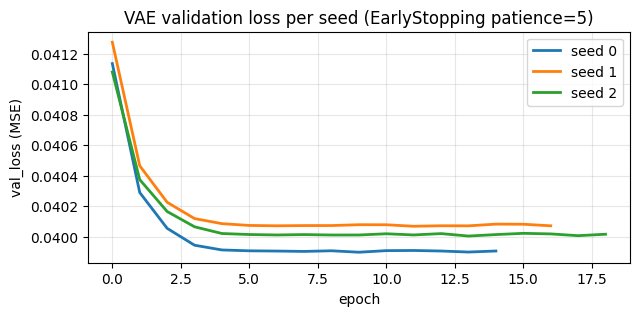

In [10]:
fig, ax = plt.subplots(figsize=(7, 3))
for seed, hist in history_per_seed.items():
    ax.plot(hist['val_loss'], label=f'seed {seed}', linewidth=2)
ax.set_xlabel('epoch'); ax.set_ylabel('val_loss (MSE)')
ax.set_title('VAE validation loss per seed (EarlyStopping patience=5)')
ax.legend(); ax.grid(alpha=0.3)
plt.show()


## 10. Ensemble (`α · VAE + (1-α) · IF`)

Both detectors first pass through their own RobustScaler so the two score scales are comparable. The `EnsembleScorer` then mixes with `α` (default 0.7) chosen via val sweep.


Ensemble val AUC: 0.7849   (paper: 0.656)


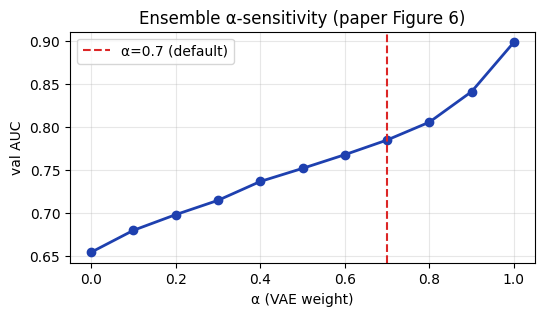

In [11]:
vae_train = recon_error(X_train, encoder, decoder)
vae_val   = recon_error(X_val,   encoder, decoder)
vae_test  = recon_error(X_test,  encoder, decoder)

ensemble = EnsembleScorer(alpha=CFG['alpha'])
ensemble.fit(vae_train, if_train)
ens_val  = ensemble.score(vae_val,  if_val)
ens_test = ensemble.score(vae_test, if_test)
print(f'Ensemble val AUC: {roc_auc_score(y_val, ens_val):.4f}   (paper: 0.656)')

# α sensitivity sweep
alphas = np.linspace(0, 1, 11)
ifs = ensemble._if_scaler.transform(if_val.reshape(-1, 1)).ravel()
vas = ensemble._vae_scaler.transform(vae_val.reshape(-1, 1)).ravel()
aucs = [roc_auc_score(y_val, a * vas + (1 - a) * ifs) for a in alphas]

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(alphas, aucs, marker='o', color='#1e40af', linewidth=2)
ax.axvline(0.7, color='#dc2626', linestyle='--', label='α=0.7 (default)')
ax.set_xlabel('α (VAE weight)'); ax.set_ylabel('val AUC')
ax.set_title('Ensemble α-sensitivity (paper Figure 6)')
ax.grid(alpha=0.3); ax.legend()
plt.show()


## 11. Threshold + test metrics

`select_threshold` is now vectorised — O(N log N) instead of O(unique × N) — handles 2 M val samples in ~1 s.

We report metrics under the F1 strategy used by the paper but **note that on DongTing's 88 %-attack val split, F1-optimal threshold collapses to "predict everything as attack"** (recall=1, FPR=1). For production deployment, threshold must be calibrated against live benign traffic, not chosen on val.


In [12]:
strategy = CFG['threshold']
t_if  = select_threshold(y_val, if_val,  strategy)
t_vae = select_threshold(y_val, vae_val, strategy)
t_ens = select_threshold(y_val, ens_val, strategy)

m_if  = compute_metrics(y_test, if_test,  t_if)
m_vae = compute_metrics(y_test, vae_test, t_vae)
m_ens = compute_metrics(y_test, ens_test, t_ens)

print(f'{"Model":<22} {"AUC":>6} {"AP":>6} {"F1":>6} {"Prec":>6} {"Recall":>7} {"FPR":>6}')
print('-' * 70)
for lbl, m in [('Isolation Forest', m_if), ('VAE', m_vae), ('Ensemble', m_ens)]:
    print(f'{lbl:<22} {m["auc_roc"]:>6.3f} {m["ap"]:>6.3f} {m["f1"]:>6.3f} '
          f'{m["precision"]:>6.3f} {m["recall_tpr"]:>7.3f} {m["fpr"]:>6.3f}')


Model                     AUC     AP     F1   Prec  Recall    FPR
----------------------------------------------------------------------
Isolation Forest        0.583  0.822  0.913  0.840   1.000  1.000
VAE                     0.809  0.949  0.915  0.843   0.999  0.977
Ensemble                0.636  0.866  0.913  0.840   1.000  1.000


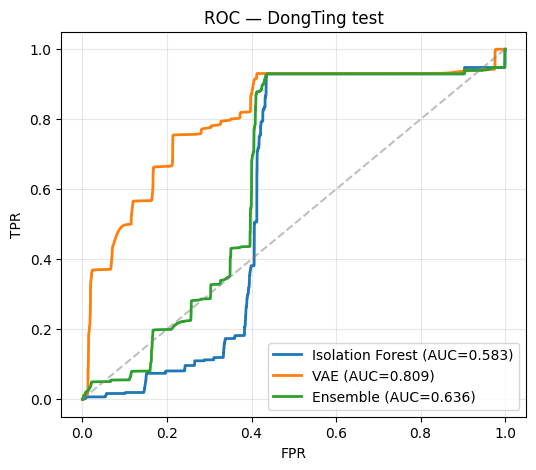

In [13]:
fig, ax = plt.subplots(figsize=(6, 5))
for lbl, scores, m in [
    ('Isolation Forest', if_test,  m_if),
    ('VAE',              vae_test, m_vae),
    ('Ensemble',         ens_test, m_ens),
]:
    fpr, tpr, _ = roc_curve(y_test, scores)
    ax.plot(fpr, tpr, linewidth=2, label=f'{lbl} (AUC={m["auc_roc"]:.3f})')
ax.plot([0, 1], [0, 1], '--', color='gray', alpha=0.5)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title('ROC — DongTing test')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.show()


## 12. Replication scorecard

Replication numbers vs the paper-reported AUCs. The val column is the cleanest like-for-like comparison.


In [14]:
# Replication scorecard — ours vs paper-reported val AUCs.
ens_val_auc = float(roc_auc_score(y_val, ens_val))
rows = [
    ('Isolation Forest', if_auc,       0.646),
    ('VAE (best)',       best_val_auc, 0.747),
    ('Ensemble',         ens_val_auc,  0.656),
]
print(f'{"Model":<18} {"Our val AUC":>12} {"Paper val AUC":>14} {"Δ vs paper":>12}')
print('-' * 60)
for name, ours, paper in rows:
    delta = ours - paper
    sign  = '+' if delta >= 0 else ''
    print(f'{name:<18} {ours:>12.4f} {paper:>14.4f} {sign}{delta:>11.4f}')


Model               Our val AUC  Paper val AUC   Δ vs paper
------------------------------------------------------------
Isolation Forest         0.6544         0.6460 +     0.0084
VAE (best)               0.8986         0.7470 +     0.1516
Ensemble                 0.7849         0.6560 +     0.1289


## 13. Save artifacts

Write VAE / ensemble / results.json for inference.


In [15]:
encoder.save_weights(str(out / 'vae_encoder.weights.h5'))
decoder.save_weights(str(out / 'vae_decoder.weights.h5'))
ensemble.save(out)

results = {
    'experiment':       (f'dongting_sliding_window_{WINDOW_LEN}_{WINDOW_STRIDE}'
                         if USE_SLIDING_WINDOW else 'dongting_build_and_train'),
    'use_sliding_window': bool(USE_SLIDING_WINDOW),
    'window_len':       WINDOW_LEN if USE_SLIDING_WINDOW else None,
    'window_stride':    WINDOW_STRIDE if USE_SLIDING_WINDOW else None,
    'n_train':          int(X_train.shape[0]),
    'n_val':            int(X_val.shape[0]),
    'n_test':           int(X_test.shape[0]),
    'feat_dim':         input_dim,
    'latent_dim':       CFG['latent_dim'],
    'hidden_dim':       CFG['hidden_dim'],
    'contamination':    CFG['contamination'],
    'ngram_n':          CFG['ngram_n'],
    'vae_seed_reports': seed_reports,
    'best_vae_seed':    int(best_seed),
    'models': {
        'isolation_forest': m_if,
        'vae':              m_vae,
        'ensemble':         {**m_ens, 'alpha': float(ensemble.alpha)},
    },
}
(out / 'results.json').write_text(json.dumps(results, indent=2))

print('Artifacts written:')
for p in sorted(out.iterdir()):
    print(f'  {p.name:40s} {p.stat().st_size//1024:5d} KB')


Artifacts written:
  ensemble_if_scaler.joblib                    0 KB
  ensemble_params.json                         0 KB
  ensemble_vae_scaler.joblib                   0 KB
  fe_report.json                               9 KB
  feature_scaler.joblib                        1 KB
  iforest.joblib                            1919 KB
  results.json                                 1 KB
  vae_decoder.weights.h5                      37 KB
  vae_encoder.weights.h5                      45 KB
